In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
tips = sns.load_dataset("tips")

print(tips.head())

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [3]:
X = tips[["total_bill"]]
y = tips["tip"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = MLPRegressor(

    hidden_layer_sizes=(20,),

    learning_rate_init=0.01,

    max_iter=1,

    warm_start=True,

    random_state=42
)

In [7]:
train_loss = []
test_loss = []

In [8]:
epochs = 100

for i in range(epochs):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)

    test_pred = model.predict(X_test)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_loss.append(train_rmse)

    test_loss.append(test_rmse)

C:\Users\gunja\anaconda3\aiml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gunja\anaconda3\aiml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gunja\anaconda3\aiml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gunja\anaconda3\aiml\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\gunja\anaconda3\aiml\Lib\site-packages\sklearn\neur

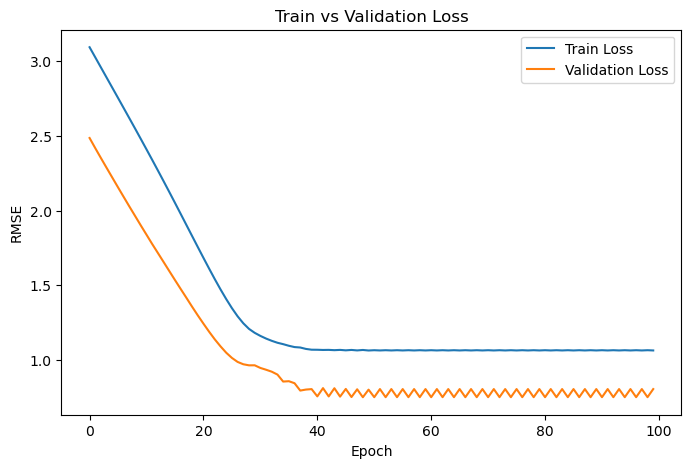

In [9]:
plt.figure(figsize=(8,5))

plt.plot(train_loss,label="Train Loss")

plt.plot(test_loss,label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("RMSE")

plt.title("Train vs Validation Loss")

plt.legend()

plt.show()

In [10]:
train_pred = model.predict(X_train)

test_pred = model.predict(X_test)